In [1]:
import numpy as np
import pandas as pd
import seaborn as sea
import matplotlib.pyplot as plt

import lightgbm
import xgboost
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.base import clone
from sklearn.model_selection import KFold, train_test_split

import shap
import optuna
import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
MAE = lambda y_true, y_pred: np.mean(np.abs(y_true - y_pred))

In [3]:
train = pd.read_csv("/kaggle/input/notebooks/khoatran311/analyzing-nonlinearities-with-gam/train_new.csv")
test  = pd.read_csv("/kaggle/input/notebooks/khoatran311/analyzing-nonlinearities-with-gam/test_new.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/the-perfect-fit/sample_submission.csv")

In [4]:
def add_fourier_features(df, col, K=5):
    x = df[col]
    x_scaled = 2 * np.pi * (x - x.min()) / (x.max() - x.min())
    for k in range(1, K+1):
        df[f"{col}_sin_{k}"] = np.sin(k * x_scaled)
        df[f"{col}_cos_{k}"] = np.cos(k * x_scaled)
        
def make_features(df):
    df_copy = df.copy()
    ## Handle outliers in x5
    df_copy.loc[df_copy["x5"]==999, "x5"] = np.nan
    ## Product of x10 and x11
    df_copy["x10_11_prod"] = df["x10"]*df["x11"]
    ## Fourier features for x2
    add_fourier_features(df_copy, "x2")
    return df_copy

In [5]:
train_new = make_features(train)

X = train_new.copy()
y = X.pop("target")

In [6]:
def cross_validate(model, model_type, X, y, scorer=MAE, n_splits=5, seed=3126):
    kfold  = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = np.zeros(n_splits) 

    for i,(train_idx,val_idx) in enumerate(kfold.split(X)):
        ## Splits data
        X_train, y_train = X.iloc[train_idx,:], y[train_idx]
        X_val,   y_val   = X.iloc[val_idx,:],   y[val_idx]

        cloned_model = clone(model)
        ## Fits model
        if model_type=="lgbm":
            cloned_model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                eval_metric="mae",
                callbacks=[lightgbm.early_stopping(100, verbose=False)])
      
        elif model_type=="xgboost":
            cloned_model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                eval_metric="mae",
                early_stopping_rounds=100, verbose=False)
            
        else: 
            cloned_model.fit(X_train, y_train)

        ## Stores the score
        scores[i] = scorer(y_val, cloned_model.predict(X_val))
    return scores

# Evaluating LGBMRegressor [4.84 leaderboard MAE]

In [7]:
# def objective(trial):
#     params = {
#         "max_depth":trial.suggest_int("max_depth", 2, 8),
#         "min_child_weight":trial.suggest_float("min_child_weight", .0001, 1, log=True),
#         "min_split_gain":trial.suggest_float("min_split_gain", .00001, 1, log=True),
#         "learning_rate":trial.suggest_float("learning_rate", .005, .3, log=True),
#         "reg_alpha":trial.suggest_float("reg_alpha", .025, 10, log=True),
#         "reg_lambda":trial.suggest_float("reg_lambda", .025, 10, log=True),
#         "colsample_bytree":trial.suggest_float("colsample_bytree", .5, 1.0),
#         "subsample_freq":trial.suggest_int("subsample_freq", 1, 10),
#         "subsample":trial.suggest_float("subsample", .5, .9),
#         "min_child_samples":trial.suggest_int("min_child_samples", 20, 250)
#     }
#     params["num_leaves"] = trial.suggest_int("num_leaves", 4, 2**params["max_depth"])
#     params["n_estimators"] = 3000
#     params["n_jobs"] = -1
#     params["random_state"] = 3126
#     params["objective"] = "regression_l1"
#     params["verbose"] = -1
    
#     model  = LGBMRegressor(**params)
#     scores = cross_validate(model, "lgbm", X, y)
#     return np.mean(scores)

# study = optuna.create_study(
#     direction="minimize",
#     sampler=optuna.samplers.TPESampler(seed=3126),
# )
# study.optimize(objective, n_trials=200)

In [8]:
params = {
    'max_depth': 2,
    'n_estimators': 3000,
    'min_child_weight': 0.1974481270777949,
    'min_split_gain': 4.3321308689871354e-05,
    'learning_rate': 0.04690351449922587,
    'reg_alpha': 0.19768717591102988,
    'reg_lambda': 0.06919335705060521,
    'colsample_bytree': 0.6350447206641506,
    'subsample_freq': 1,
    'subsample': 0.5679507027085122,
    'min_child_samples': 35,
    'num_leaves': 4
}
params["n_jobs"] = -1
params["random_state"] = 3126
params["objective"] = "regression_l1"
params["verbose"] = -1

model  = LGBMRegressor(**params)
scores = cross_validate(model, "lgbm", X, y)
print(f"Mean MAE Score: {np.mean(scores):.3f}")
print(f"SD MAE Score: {np.std(scores):.3f}")

Mean MAE Score: 3.250
SD MAE Score: 0.205


In [9]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=.3, shuffle=True, random_state=3126)
model = LGBMRegressor(**params)
model.fit(X_train, y_train)

LGBMRegressor(colsample_bytree=0.6350447206641506,
              learning_rate=0.04690351449922587, max_depth=2,
              min_child_samples=35, min_child_weight=0.1974481270777949,
              min_split_gain=4.3321308689871354e-05, n_estimators=3000,
              n_jobs=-1, num_leaves=4, objective='regression_l1',
              random_state=3126, reg_alpha=0.19768717591102988,
              reg_lambda=0.06919335705060521, subsample=0.5679507027085122,
              subsample_freq=1, verbose=-1)

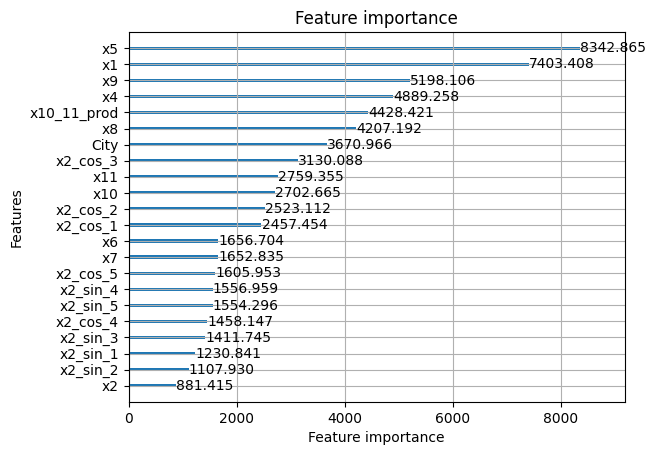

In [10]:
lightgbm.plot_importance(model, importance_type="gain")
plt.show()

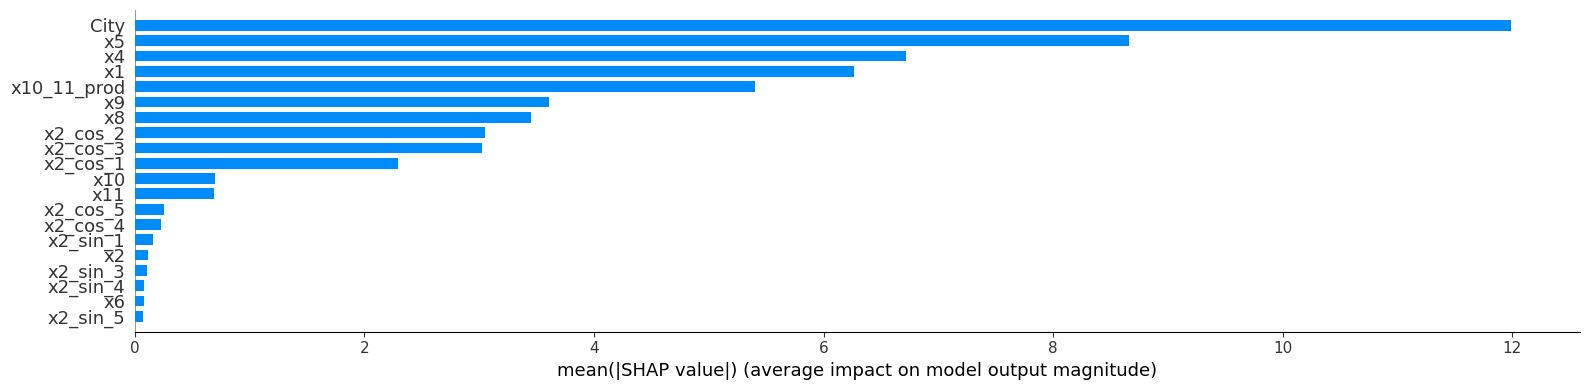

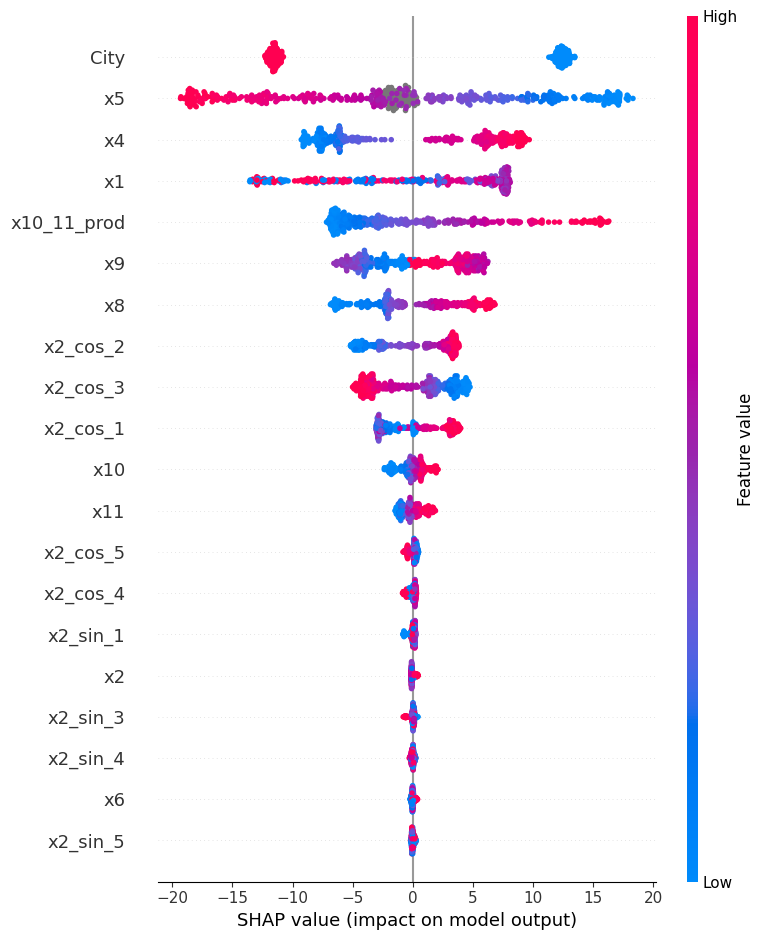

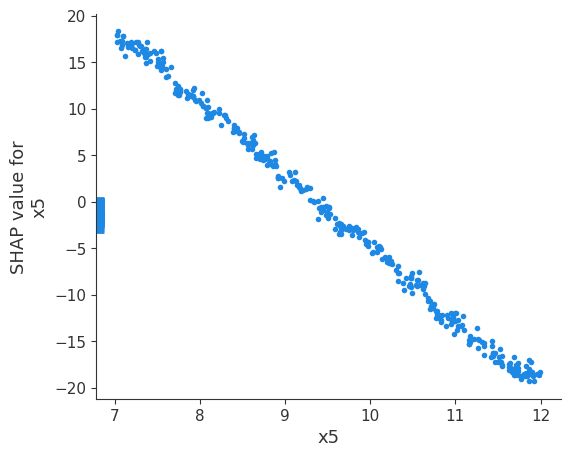

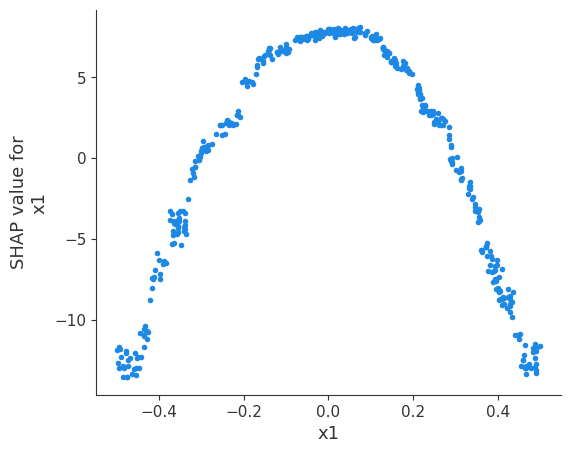

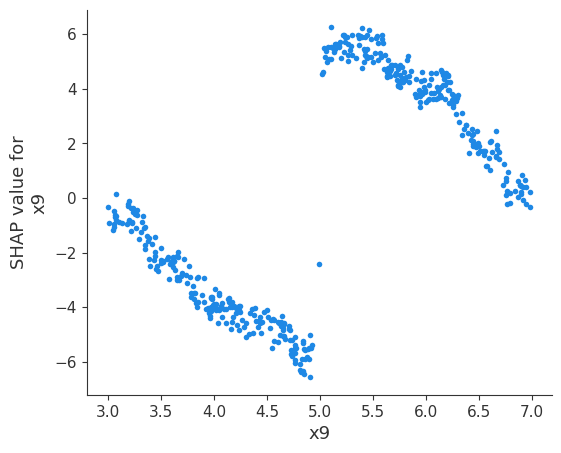

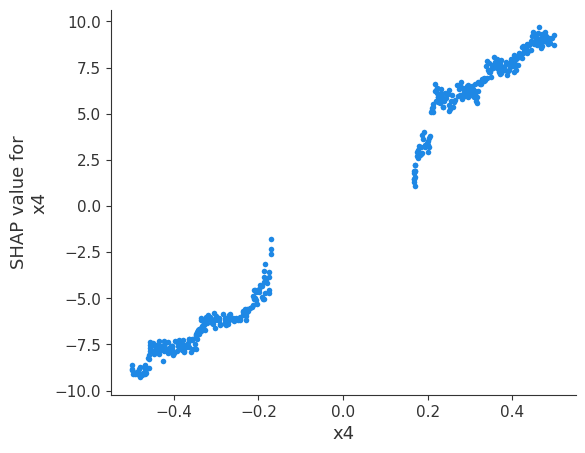

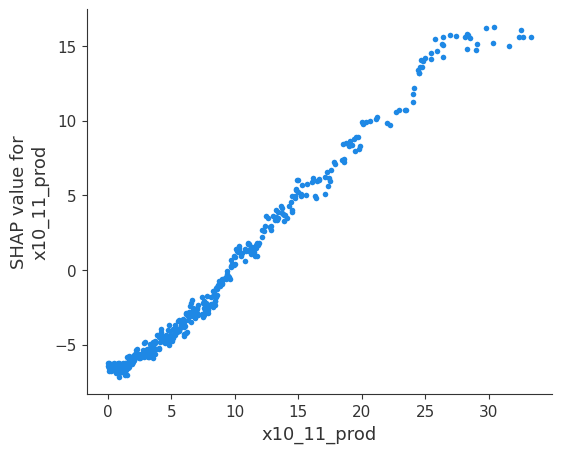

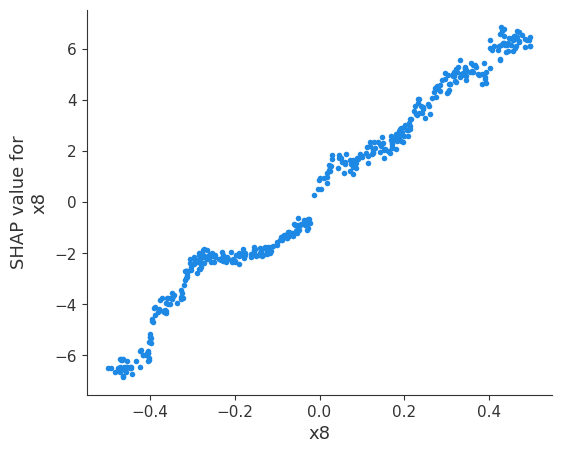

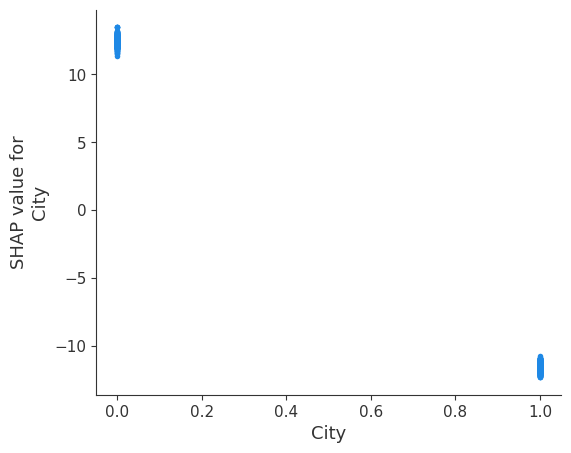

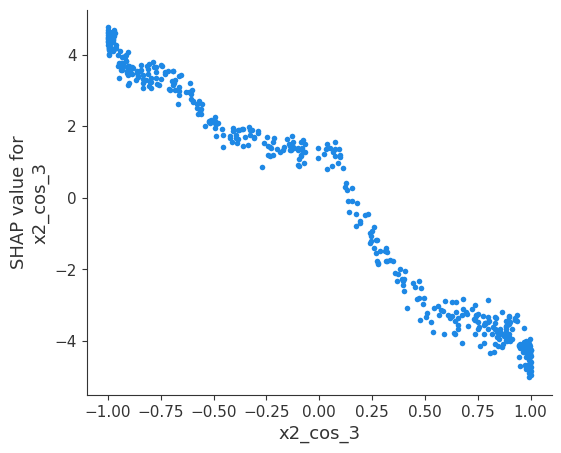

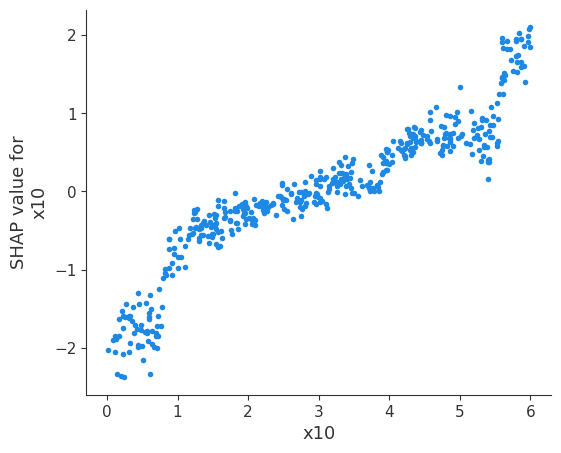

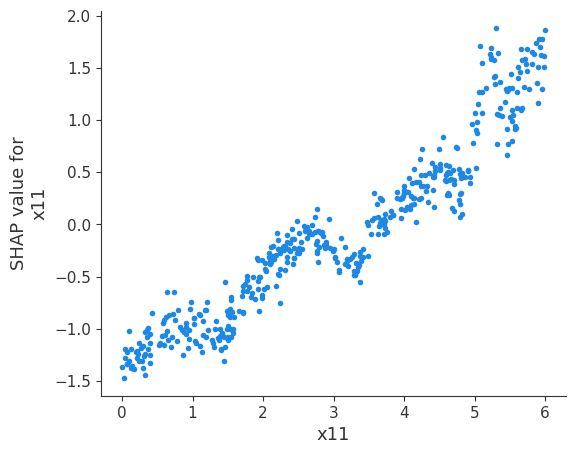

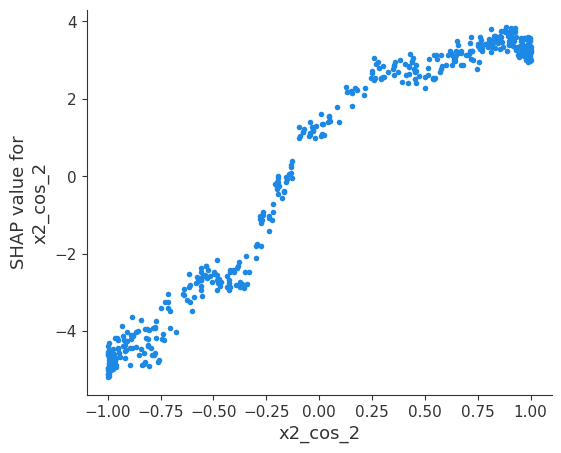

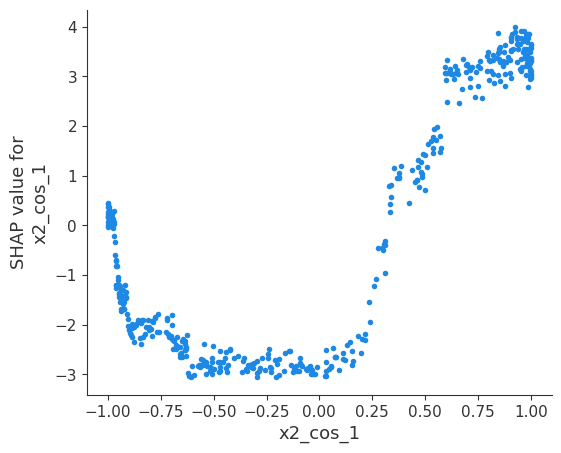

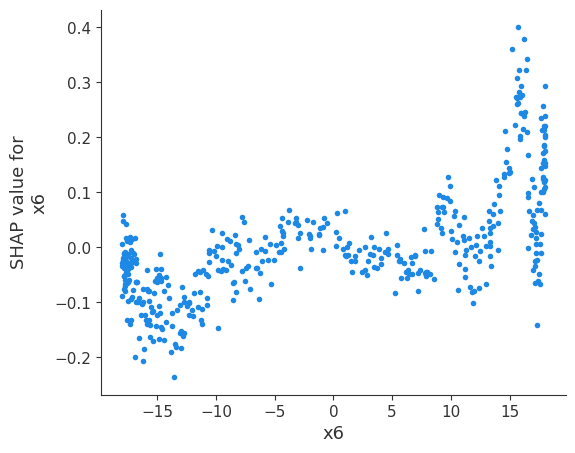

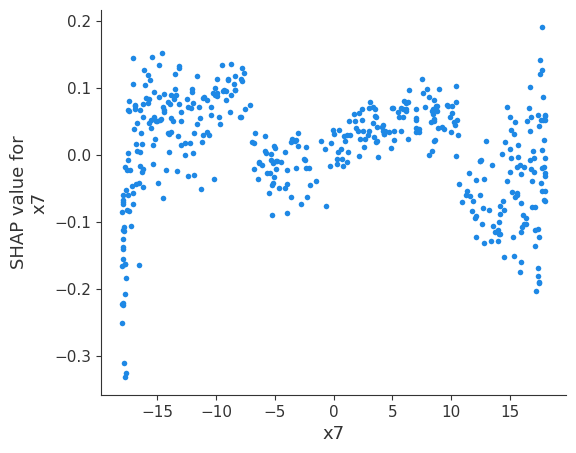

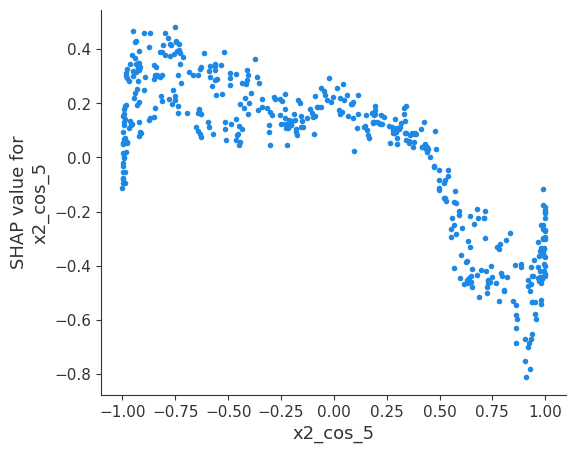

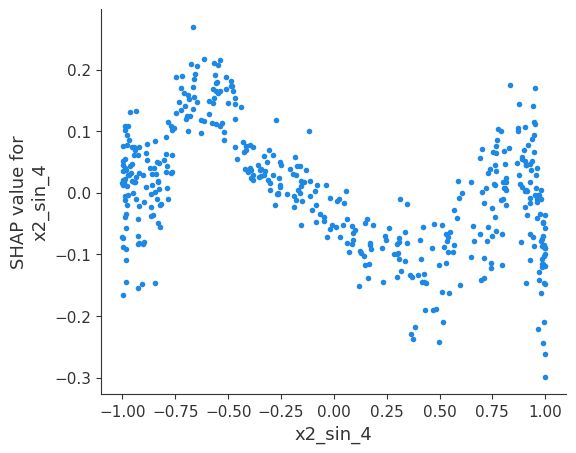

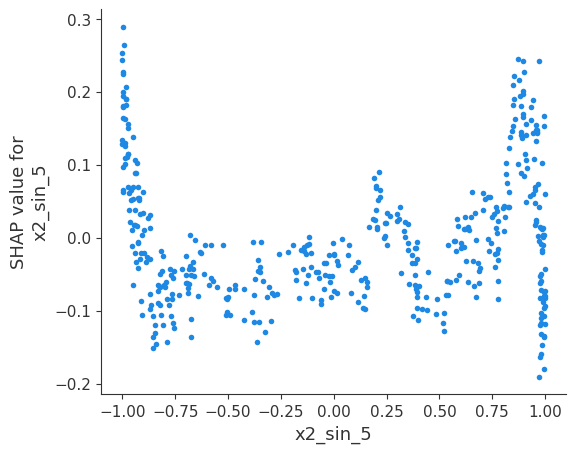

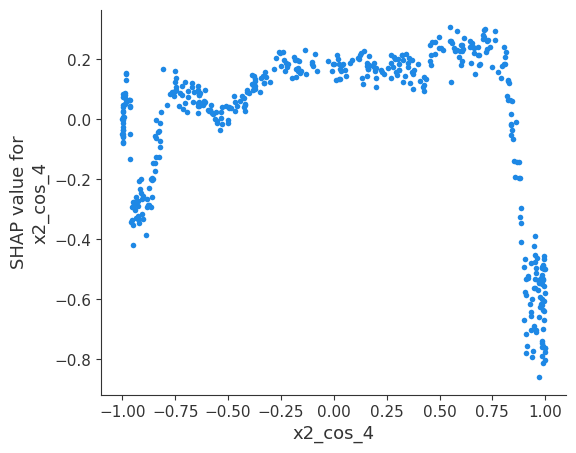

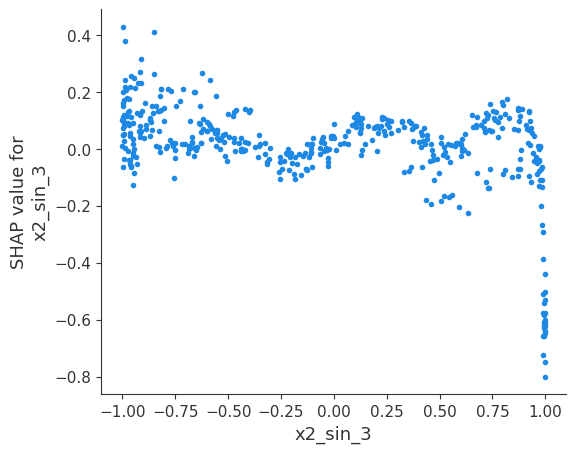

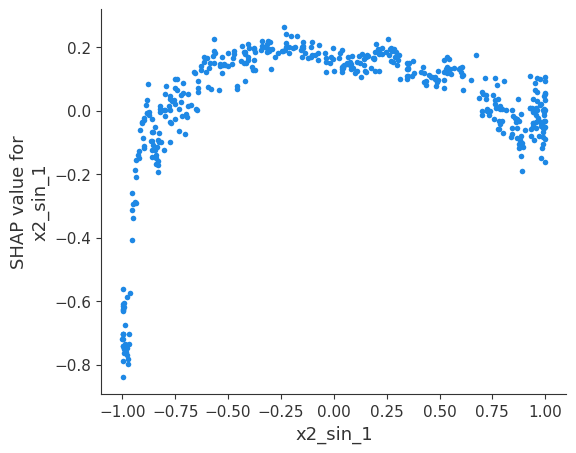

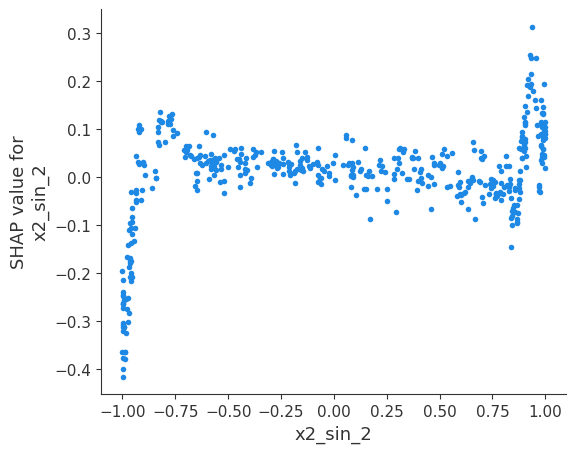

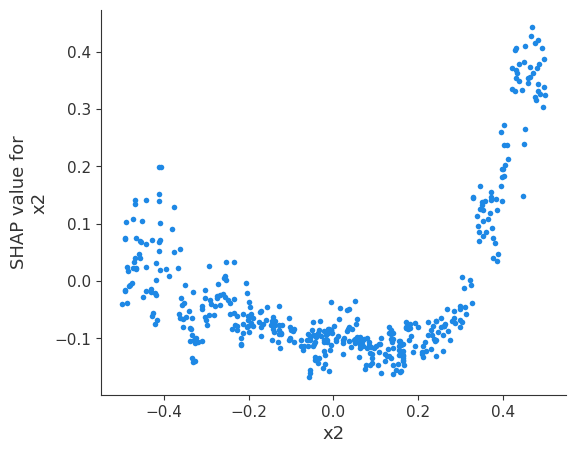

In [11]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

shap.summary_plot(shap_values, X_val, plot_type="bar", plot_size=(16,4))
shap.summary_plot(shap_values, X_val)

top_predictive_features = ["x5", "x1", "x9", "x4", "x10_11_prod", "x8", "City", 
                           "x2_cos_3", "x10", "x11", "x2_cos_2", "x2_cos_1",
                           "x6", "x7", "x2_cos_5", "x2_sin_4", "x2_sin_5", "x2_cos_4",
                           "x2_sin_3", "x2_sin_1", "x2_sin_2", "x2"
                          ]
for feature in top_predictive_features:
    shap.dependence_plot(
        feature,
        shap_values,
        X_val,
        interaction_index=None
    )

# Submission

In [12]:
model = LGBMRegressor(**params)
model.fit(X,y)

test_new = make_features(test)
sample_submission.target = model.predict(test_new)
sample_submission.to_csv("submission.csv", index=False)